In [1]:
%matplotlib inline
import math
import numpy as np
import matplotlib.pyplot as plt
import openmc
import openmc.model

/home/martinzn16/miniforge3/envs/openmc-env/lib/python3.13/site-packages/openmc/config.py:110: UserWarning: Path '/mnt/c/Users/marti/OneDrive/Escritorio/FH/Master_thesis/openmc/mcnp_endfb71/mcnp_endfb71/cross_sections.xml^T^Z' does not exist.
  warnings.warn(f"Path '{stored_path}' does not exist.", UserWarning)


In [2]:
fuel = openmc.Material(name='MHTGR Fresh Fuel Kernel')
fuel.add_nuclide('U235', 3.70E-03, 'ao')
fuel.add_nuclide('U238', 1.99E-02, 'ao')
fuel.add_nuclide('O16', 3.55E-02, 'ao')
fuel.add_element('C', 1.18E-02, 'ao') # C-nat
fuel.set_density('atom/b-cm', 3.70E-03 + 1.99E-02 + 3.55E-02 + 1.18E-02)

buff = openmc.Material(name='Fuel Buffer')
buff.add_element('C', 5.02E-02, 'ao')
buff.add_s_alpha_beta('c_Graphite')
buff.set_density('atom/b-cm', 5.02E-02)

PyC1 = openmc.Material(name='Fuel IPyC')
PyC1.add_element('C', 9.53E-02, 'ao')
PyC1.add_s_alpha_beta('c_Graphite')
PyC1.set_density('atom/b-cm', 9.53E-02)

SiC = openmc.Material(name='Fuel SiC')
SiC.add_nuclide('Si28', 4.43E-02, 'ao')
SiC.add_nuclide('Si29', 2.25E-03, 'ao')
SiC.add_nuclide('Si30', 1.49E-03, 'ao')
SiC.add_element('C', 4.81E-02, 'ao') # C-nat
SiC.set_density('atom/b-cm', 4.43E-02 + 2.25E-03 + 1.49E-03 + 4.81E-02)

PyC2 = openmc.Material(name='Fuel OPyC')
PyC2.add_element('C', 9.53E-02, 'ao')
PyC2.add_s_alpha_beta('c_Graphite')
PyC2.set_density('atom/b-cm', 9.53E-02)

fuel_matrix = openmc.Material(name='Fuel Compact Matrix')
fuel_matrix.add_element('C', 8.27E-02, 'ao')
fuel_matrix.add_s_alpha_beta('c_Graphite')
fuel_matrix.set_density('atom/b-cm', 8.27E-02)


In [10]:
# =============================================================================
# BURNABLE POISON (LBP) MATERIALS (Table III-3)
# =============================================================================
b4c_kernel = openmc.Material(name='LBP B4C Kernel')
b4c_kernel.add_nuclide('B10', 2.14E-02, 'ao')
b4c_kernel.add_nuclide('B11', 8.63E-02, 'ao')
b4c_kernel.add_element('C', 2.69E-02, 'ao') # C-nat
b4c_kernel.set_density('atom/b-cm', 2.14E-02 + 8.63E-02 + 2.69E-02)

lbp_buffer = openmc.Material(name='LBP Buffer')
lbp_buffer.add_element('C', 5.02E-02, 'ao')
lbp_buffer.add_s_alpha_beta('c_Graphite')
lbp_buffer.set_density('atom/b-cm', 5.02E-02)

lbp_pyc = openmc.Material(name='LBP PyC')
lbp_pyc.add_element('C', 9.38E-02, 'ao')
lbp_pyc.add_s_alpha_beta('c_Graphite')
lbp_pyc.set_density('atom/b-cm', 9.38E-02)

lbp_matrix = openmc.Material(name='BP Compact Matrix')
lbp_matrix.add_element('C', 6.87E-02, 'ao')
lbp_matrix.add_s_alpha_beta('c_Graphite')
lbp_matrix.set_density('atom/b-cm', 6.87E-02)
# =============================================================================
# MACRO-STRUCTURE MATERIALS (Table III-3)
# =============================================================================
graphite = openmc.Material(name='Block Graphite')
graphite.add_element('C', 9.28E-02, 'ao')
graphite.add_s_alpha_beta('c_Graphite')
graphite.set_density('atom/b-cm', 9.28E-02)

helium = openmc.Material(name='Coolant Helium')
helium.add_nuclide('He4', 2.46E-05, 'ao')
helium.set_density('atom/b-cm', 2.46E-05)
# DEFINE LBP BOUNDARIES (MHTGR-350 Table 1.3)
# =============================================================================
r_lbp_compact = openmc.ZCylinder(r=0.5715)
r_lbp_hole    = openmc.ZCylinder(r=0.6350)

min_z = openmc.ZPlane(z0=-1.0, boundary_type='reflective')
max_z = openmc.ZPlane(z0=1.0, boundary_type='reflective')
# PACK LBP PARTICLES INTO COMPACT
# =============================================================================
lbp_compact_region = -r_lbp_compact & +min_z & -max_z
# CREATE LBP PARTICLE UNIVERSE
# Radii converted to cm: Kernel (0.0100), Buffer (0.0118), PyC (0.0141)
lbp_spheres = [openmc.Sphere(r=radius) for radius in [0.0100, 0.0118, 0.0141]]
lbp_outer_radius = 0.0141
lbp_outer_sphere = openmc.Sphere(r=lbp_outer_radius)

lbp_cells = [
    openmc.Cell(fill=b4c_kernel, region=-lbp_spheres[0]),
    openmc.Cell(fill=lbp_buffer, region=+lbp_spheres[0] & -lbp_spheres[1]),
    openmc.Cell(fill=lbp_pyc, region=+lbp_spheres[1] & -lbp_outer_sphere)
]
lbp_particle_univ = openmc.Universe(cells=lbp_cells)

# PACK LBP PARTICLES INTO COMPACT
# =============================================================================
lbp_compact_region = -r_lbp_compact & +min_z & -max_z

print("Packing LBP particles... (pf=0.109)")
# Packing fraction of 0.109 specified by the benchmark
lbp_centers = openmc.model.pack_spheres(radius=lbp_outer_radius, region=lbp_compact_region, pf=0.109, seed=9876)
lbp_particles = [openmc.model.TRISO(lbp_outer_radius, lbp_particle_univ, c) for c in lbp_centers]

lbp_ll, lbp_ur = lbp_compact_region.bounding_box
lbp_shape = (5, 5, 5)
lbp_pitch = (lbp_ur - lbp_ll) / lbp_shape
# The LBP particles are embedded in their specific low-density graphite matrix
lbp_lattice = openmc.model.create_triso_lattice(lbp_particles, lbp_ll, lbp_pitch, lbp_shape, lbp_matrix)


Packing LBP particles... (pf=0.109)


<Axes: xlabel='x [cm]', ylabel='y [cm]'>

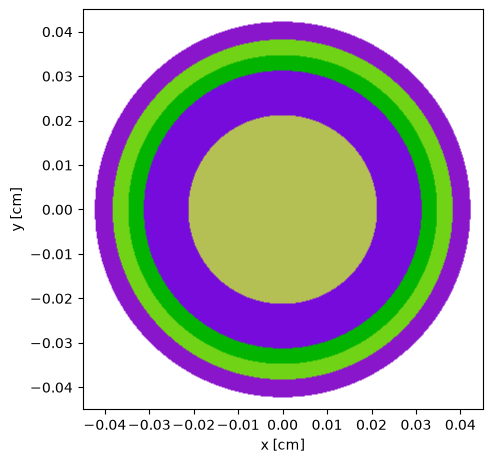

In [11]:
spheres = [openmc.Sphere(r=radius) for radius in [0.02125, 0.03125, 0.03475, 0.03825]]
outer_radius = 0.04225 # OPyC outer boundary
outer_sphere = openmc.Sphere(r=outer_radius)

cells = [
    openmc.Cell(fill=fuel, region=-spheres[0]),
    openmc.Cell(fill=buff, region=+spheres[0] & -spheres[1]),
    openmc.Cell(fill=PyC1, region=+spheres[1] & -spheres[2]),
    openmc.Cell(fill=SiC, region=+spheres[2] & -spheres[3]),
    openmc.Cell(fill=PyC2, region=+spheres[3] & -outer_sphere)
]
triso_univ = openmc.Universe(cells=cells)
triso_univ.plot(
    origin=(0.0, 0.0, 0.0), 
    width=(0.09, 0.09), 
    pixels=(400, 400), 
    color_by='cell'
)

Packing TRISO particles... (this might take a few minutes for pf=0.350)


<Axes: xlabel='x [cm]', ylabel='y [cm]'>

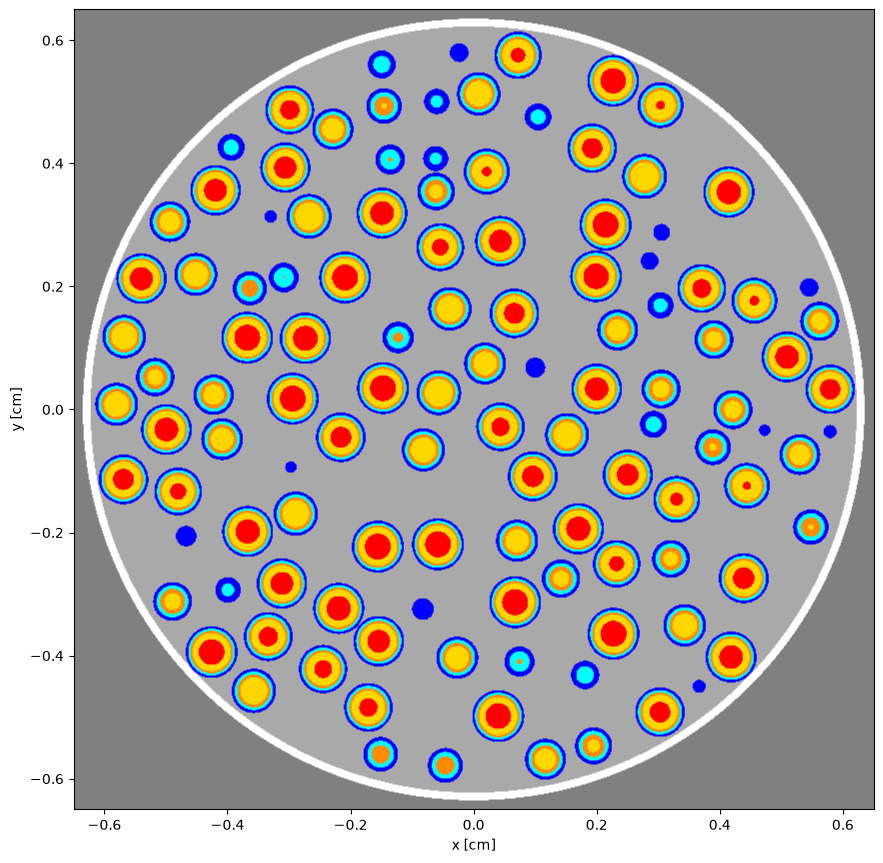

In [12]:
# Exact geometry boundaries from Table 1.3 and Table 1.4
r_fuel_compact       = openmc.ZCylinder(r=0.6225)
r_fuel_hole          = openmc.ZCylinder(r=0.6350) 
r_coolant_hole_large = openmc.ZCylinder(r=0.7940)
r_coolant_hole_small = openmc.ZCylinder(r=0.6350)

min_z = openmc.ZPlane(z0=-1.0, boundary_type='reflective')
max_z = openmc.ZPlane(z0=1.0, boundary_type='reflective')
compact_region = -r_fuel_compact & +min_z & -max_z

print("Packing TRISO particles... (this might take a few minutes for pf=0.350)")
# Packing fraction updated to 0.350 (Table 1.4)
centers = openmc.model.pack_spheres(radius=outer_radius, region=compact_region, pf=0.350, seed=1248)
trisos = [openmc.model.TRISO(outer_radius, triso_univ, c) for c in centers]

lower_left, upper_right = compact_region.bounding_box
# Add a 0.01 cm buffer to the tracking lattice boundaries
lower_left = lower_left - 0.01
upper_right = upper_right + 0.01
shape = (5, 5, 5) 
pitch = (upper_right - lower_left) / shape

# CRITICAL FIX: Use fuel_matrix instead of graphite for the background
triso_lattice = openmc.model.create_triso_lattice(trisos, lower_left, pitch, shape, fuel_matrix)

# Fuel Pin Universe
fuel_univ = openmc.Universe(cells=[
    openmc.Cell(fill=triso_lattice, region=compact_region),
    openmc.Cell(fill=helium, region=+r_fuel_compact & -r_fuel_hole & +min_z & -max_z),
    openmc.Cell(fill=graphite, region=+r_fuel_hole & +min_z & -max_z)
])

# Large Coolant Pin Universe
coolant_large_univ = openmc.Universe(cells=[
    openmc.Cell(fill=helium, region=-r_coolant_hole_large & +min_z & -max_z),
    openmc.Cell(fill=graphite, region=+r_coolant_hole_large & +min_z & -max_z)
])

# Small Coolant Pin Universe (Table 1.3 specifies 6 small coolant holes)
coolant_small_univ = openmc.Universe(cells=[
    openmc.Cell(fill=helium, region=-r_coolant_hole_small & +min_z & -max_z),
    openmc.Cell(fill=graphite, region=+r_coolant_hole_small & +min_z & -max_z)
])

# Lumped Burnable Poison (LBP) Pin Universe
bp_univ = openmc.Universe(cells=[
    openmc.Cell(fill=lbp_lattice, region=lbp_compact_region),
    openmc.Cell(fill=helium, region=+r_lbp_compact & -r_lbp_hole & +min_z & -max_z),
    openmc.Cell(fill=graphite, region=+r_lbp_hole & +min_z & -max_z)
])

# Solid Graphite Edge Universe
graph_univ = openmc.Universe(cells=[openmc.Cell(fill=graphite, region=+min_z & -max_z)])
# =============================================================================
# 3b. GENERATE 16 UNIQUE REPORTING PIN UNIVERSES
# =============================================================================
reporting_univs = []

# Loop to create 16 unique universes with distinct cell IDs
for i in range(16):
    c_triso = openmc.Cell(fill=triso_lattice, region=compact_region)
    c_he    = openmc.Cell(fill=helium, region=+r_fuel_compact & -r_fuel_hole & +min_z & -max_z)
    c_graph = openmc.Cell(fill=graphite, region=+r_fuel_hole & +min_z & -max_z)
    
    u = openmc.Universe(name=f'Reporting_Fuel_Pin_{i+1}', cells=[c_triso, c_he, c_graph])
    reporting_univs.append(u)

# Create the spatial filter using these specific universes
pin_filter = openmc.UniverseFilter(reporting_univs)

# =============================================================================
# 3c. GENERATE 3 UNIQUE REPORTING BP UNIVERSES
# =============================================================================
reporting_bp_univs = []

# Loop to create 3 unique universes for the Burnable Poison reporting pins
for i in range(3):
    c_bp_triso = openmc.Cell(fill=lbp_lattice, region=lbp_compact_region)
    c_bp_he    = openmc.Cell(fill=helium, region=+r_lbp_compact & -r_lbp_hole & +min_z & -max_z)
    c_bp_graph = openmc.Cell(fill=graphite, region=+r_lbp_hole & +min_z & -max_z)
    
    u_bp = openmc.Universe(name=f'Reporting_BP_Pin_{i+1}', cells=[c_bp_triso, c_bp_he, c_bp_graph])
    reporting_bp_univs.append(u_bp)

# Create a separate spatial filter for the BP pins
bp_pin_filter = openmc.UniverseFilter(reporting_bp_univs)

# Plot a cross-section of the fuel pin containing the TRISOs
fuel_univ.plot(
    origin=(0.0, 0.0, 0.0),
    width=(1.3, 1.3),  # Zoomed into the ~1.25 cm diameter fuel compact
    pixels=(800, 800),
    basis='xy',
    color_by='material',
    colors={
        helium: 'white',
        fuel: 'red',
        buff: 'gold',
        PyC1: 'darkorange',
        SiC: 'cyan',
        PyC2: 'blue',
        fuel_matrix: 'darkgray', # Added fuel_matrix color mapping
        graphite: 'gray'
    }
)

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

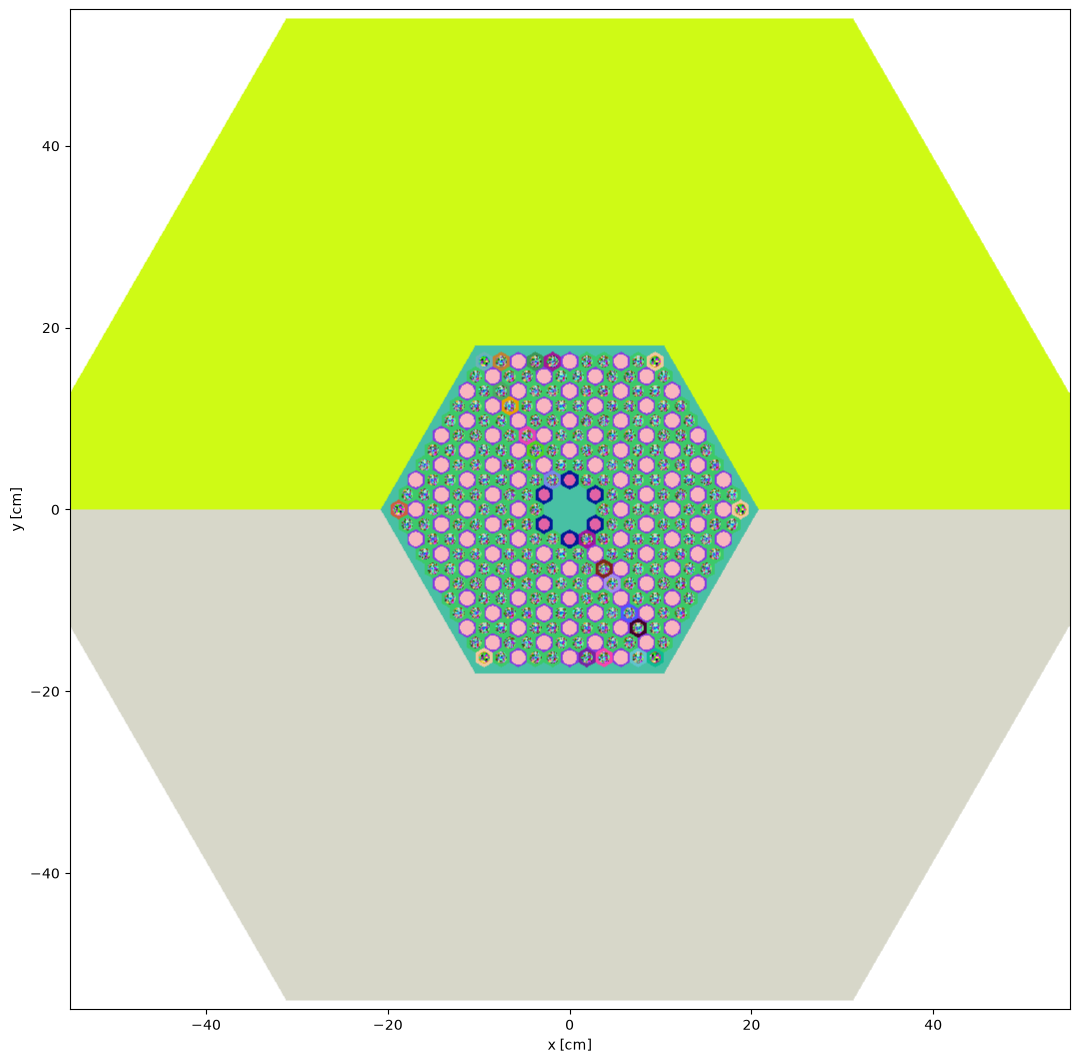

In [13]:
# =============================================================================
# 4. PROGRAMMATIC HEXAGONAL MACRO-LATTICE
# =============================================================================
lattice = openmc.HexLattice(name='MHTGR-350 Fuel Block')
lattice.center = (0.0, 0.0)
lattice.pitch = (1.88,) 
lattice.orientation = 'x' # Forces the pointy-top orientation
lattice.outer = graph_univ

F = fuel_univ
C = coolant_large_univ
S = coolant_small_univ
B = bp_univ
G = graph_univ

# Use your perfected, flattened arrays to prevent the "swirl" phase-shift
ring_10 = [
    B, F, C, F, F, C, F, F, C, F,
    reporting_bp_univs[0], reporting_univs[0], C, reporting_univs[1], reporting_univs[2], C, F, F, C, F,
    B, F, C, F, F, C, F, F, C, F,
    reporting_bp_univs[1], F, C, F, F, C, F, F, C, F,
    reporting_bp_univs[2], reporting_univs[3], C, reporting_univs[4], reporting_univs[5], C, F, F, C, F,
    B, F, C, F, F, C, F, F, C, F
]

ring_9 = [
    C, F, F, C, F, F, C, F, F,
    C, F, F, C, F, F, C, F, F,
    C, F, F, C, F, F, C, F, F,
    C, F, F, C, F, F, C, F, F,
    C, F, F, C, F, F, C, F, F,
    C, F, F, C, F, F, C, F, F
]

ring_8 = [
    F, C, F, F, C, F, F, C,
    reporting_univs[6], C, F, F, C, F, F, C,
    F, C, F, F, C, F, F, C,
    F, C, F, F, C, F, F, C,
    reporting_univs[7], C, F, F, C, F, F, C,
    F, C, F, F, C, F, F, C
]

ring_7 = [
    F, F, C, F, F, C, F,
    reporting_univs[8], F, C, F, F, C, F,
    F, F, C, F, F, C, F,
    F, F, C, F, F, C, F,
    reporting_univs[9], F, C, F, F, C, F,
    F, F, C, F, F, C, F
]

ring_6 = [
    C, F, F, C, F, F,
    C, F, F, C, F, F,
    C, F, F, C, F, F,
    C, F, F, C, F, F,
    C, F, F, C, F, F,
    C, F, F, C, F, F
]

ring_5 = [
    F, C, F, F, C,
    reporting_univs[10], C, F, F, C,
    F, C, F, F, C,
    F, C, F, F, C,
    reporting_univs[11], C, F, F, C,
    F, C, F, F, C
]

ring_4 = [
    F, F, C, F,
    reporting_univs[12], F, C, F,
    F, F, C, F,
    F, F, C, F,
    reporting_univs[13], F, C, F,
    F, F, C, F
]

ring_3 = [
    C, F, F,
    C, F, F,
    C, F, F,
    C, F, F,
    C, F, F,
    C, F, F
]

ring_2 = [
    F, S,
    reporting_univs[14], S,
    F, S,
    F, S,
    reporting_univs[15], S,
    F, S
]

ring_1 = [
    G, G, G, G, G, G
]

ring_0 = [G]

lattice.universes = [
    ring_10, ring_9, ring_8, ring_7, ring_6, 
    ring_5, ring_4, ring_3, ring_2, ring_1, ring_0
]

# =============================================================================
# 5. 2D RADIAL SUPER-CELL ARCHITECTURE & MATERIALS
# =============================================================================

# 1. Homogenized Reflector (Data from Table III-4)
homogenized_reflector = openmc.Material(name='Top Reflector')
homogenized_reflector.add_element('C', 8.63E-02, 'ao')
homogenized_reflector.add_nuclide('B10', 2.76E-08, 'ao')
homogenized_reflector.add_s_alpha_beta('c_Graphite')
# Set total density exactly to the sum of the atom/b-cm values
homogenized_reflector.set_density('atom/b-cm', 8.63E-02 + 2.76E-08)

# 2. Homogenized Burned Fuel (Data from Table III-4)
homogenized_burned_fuel = openmc.Material(name='Bottom Burned Fuel')

burned_isotopes = {
    'U234': 4.92E-10, 'U235': 1.83E-05, 'U236': 3.30E-06, 'U238': 1.78E-04,
    'Np237': 2.49E-07, 'Np239': 5.33E-08, 'Pu238': 4.97E-08, 'Pu239': 3.51E-06,
    'Pu240': 5.96E-07, 'Pu241': 6.42E-07, 'Pu242': 9.34E-08, 'Am241': 1.83E-08,
    'Am243': 1.31E-08, 'Cm242': 3.21E-09, 'Cm243': 5.01E-11, 'Cm244': 2.53E-09,
    'Cm245': 1.38E-10, 'Cm246': 4.12E-12, 'Kr83': 3.36E-08, 'Sr90': 7.82E-07,
    'Mo95': 8.02E-07, 'Tc99': 8.82E-07, 'Rh103': 4.34E-07, 'Rh105': 9.75E-10,
    'Pd107': 1.26E-07, 'Xe131': 3.68E-07, 'Xe135': 3.03E-10, 'Cs133': 9.56E-07,
    'Cs134': 9.75E-08, 'Nd143': 7.65E-07, 'Nd145': 5.52E-07, 'Pm147': 1.58E-07,
    'Sm149': 3.77E-09, 'Sm151': 1.63E-08, 'Sm152': 6.93E-08, 'Eu153': 6.97E-08,
    'Eu154': 1.47E-08, 'Eu155': 3.82E-09, 'O16': 3.06E-04, 'Si28': 5.07E-04, 
    'Si29': 2.57E-05, 'Si30': 1.70E-05
}

# Programmatically add the explicit isotopic inventory
for nuc, dens in burned_isotopes.items():
    homogenized_burned_fuel.add_nuclide(nuc, dens, 'ao')

# Add the bulk graphite matrix and thermal scattering data
homogenized_burned_fuel.add_element('C', 6.90E-02, 'ao')
homogenized_burned_fuel.add_s_alpha_beta('c_Graphite')

# Set total density exactly to the sum of the atom/b-cm values
total_dens = sum(burned_isotopes.values()) + 6.90E-02
homogenized_burned_fuel.set_density('atom/b-cm', total_dens)

# 3. Finalize CSG Prisms (Keeping the perfect 'x' pointy-topped orientation)
core_prism = openmc.model.HexagonalPrism(edge_length=36.0 / math.sqrt(3), orientation='x')
macro_prism = openmc.model.HexagonalPrism(edge_length=108.0 / math.sqrt(3), orientation='x', boundary_type='reflective')

mid_plane = openmc.YPlane(y0=0.0)

region_fresh = -core_prism & +min_z & -max_z
region_refl  = +core_prism & -macro_prism & +mid_plane & +min_z & -max_z
region_burn  = +core_prism & -macro_prism & -mid_plane & +min_z & -max_z

cell_fresh = openmc.Cell(fill=lattice, region=region_fresh)
cell_refl  = openmc.Cell(fill=homogenized_reflector, region=region_refl)
cell_burn  = openmc.Cell(fill=homogenized_burned_fuel, region=region_burn)

geom = openmc.Geometry(openmc.Universe(cells=[cell_fresh, cell_refl, cell_burn]))
# 4. Define the root universe HERE before plotting!
root_univ = openmc.Universe(cells=[cell_fresh, cell_refl, cell_burn])
geom = openmc.Geometry(root_univ)

# Create a dictionary specifically for CELL-level colors
plot_colors = {}

# 1. Mute the standard background pins
for cell in fuel_univ.cells.values(): plot_colors[cell] = 'lightgray'
for cell in coolant_large_univ.cells.values(): plot_colors[cell] = 'white'
for cell in coolant_small_univ.cells.values(): plot_colors[cell] = 'white'
for cell in bp_univ.cells.values(): plot_colors[cell] = 'darkblue'
for cell in graph_univ.cells.values(): plot_colors[cell] = 'gray'

# 2. Color the massive top and bottom macro-regions
plot_colors[cell_refl] = 'purple'
plot_colors[cell_burn] = 'orange'

# 3. Dynamically add the cells inside the 16 reporting fuel universes as NEON GREEN
for u in reporting_univs:
    for cell in u.cells.values():
        plot_colors[cell] = 'lime'

# 4. Dynamically add the cells inside the 3 reporting BP universes as BRIGHT YELLOW
for u in reporting_bp_univs:
    for cell in u.cells.values():
        plot_colors[cell] = 'yellow'

# 5. Plot the full super-cell
root_univ.plot(
    origin=(0.0, 0.0, 0.0),
    width=(110.0, 110.0),  
    pixels=(1000, 1000),
    basis='xy',
    color_by='cell',       # Must be set to 'cell' for this dictionary to work
    colors=plot_colors
)

In [14]:
# =============================================================================
# FINAL TALLIES & SPECTRAL INDICES SETUP
# =============================================================================
tallies = openmc.Tallies()
energy_filter = openmc.EnergyFilter([0.0, 4.95, 20.0e6])
pin_filter = openmc.UniverseFilter(reporting_univs)
bp_pin_filter = openmc.UniverseFilter(reporting_bp_univs)

# U-235 Tally (Fission and Capture for delta_235 and c/f_235)
tally_u235 = openmc.Tally(name='U-235 Rates')
tally_u235.filters = [pin_filter, energy_filter]
tally_u235.nuclides = ['U235']
tally_u235.scores = ['fission', '(n,gamma)']
tallies.append(tally_u235)

# U-238 Tally (Fission and Capture for rho_238 and delta_238)
tally_u238 = openmc.Tally(name='U-238 Rates')
tally_u238.filters = [pin_filter, energy_filter]
tally_u238.nuclides = ['U238']
tally_u238.scores = ['fission', '(n,gamma)']
tallies.append(tally_u238)

# BP Flux Tally
tally_bp_flux = openmc.Tally(name='BP Pin Spectrum')
tally_bp_flux.filters = [bp_pin_filter, energy_filter]
tally_bp_flux.scores = ['flux']
tallies.append(tally_bp_flux)

tallies.export_to_xml()

Generating high-resolution macro-plot of the radial super-cell...


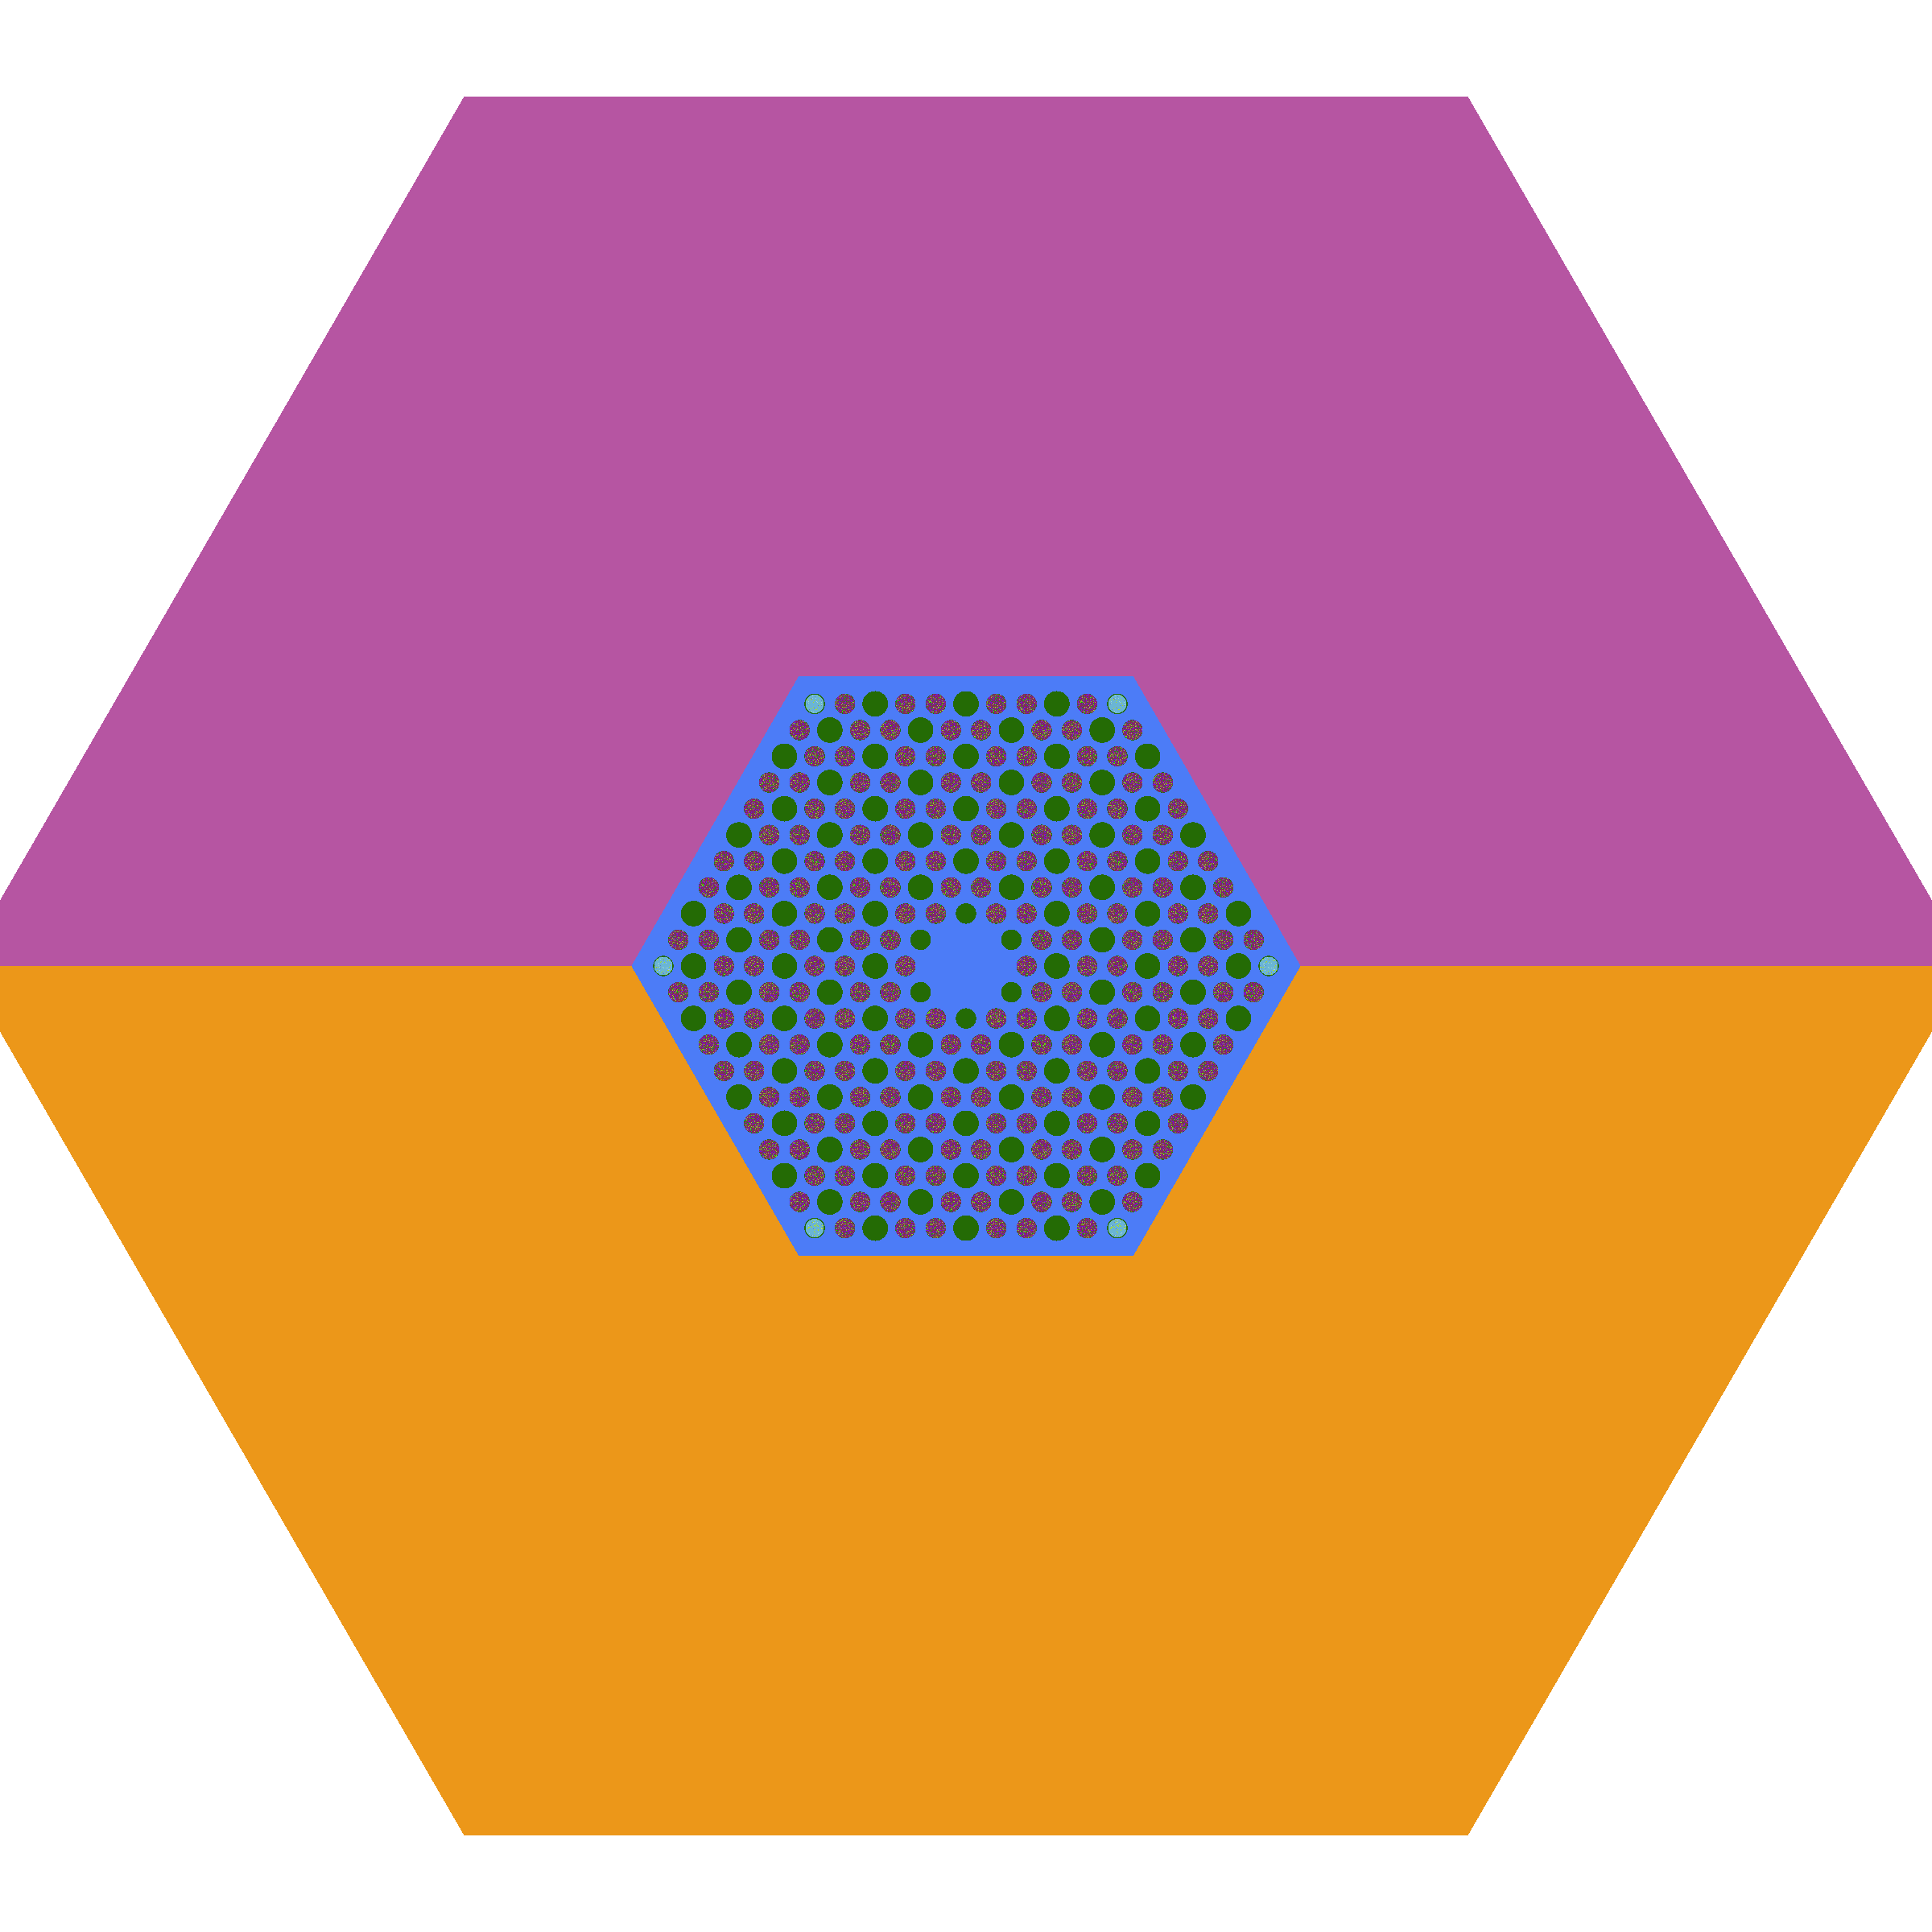


Switching to eigenvalue mode and writing production XMLs...
All XML files successfully written to disk. Ready for execution.


In [15]:
# =============================================================================
# VISUALIZE GEOMETRY AND EXPORT XML ARCHITECTURE
# =============================================================================

# --- 1. EXPORT CORE ARCHITECTURE ---
geom.export_to_xml()
openmc.Materials(geom.get_all_materials().values()).export_to_xml()

# --- 2. GENERATE HIGH-RESOLUTION MACRO-PLOT ---
print("Generating high-resolution macro-plot of the radial super-cell...")
plot = openmc.Plot()
plot.origin = (0.0, 0.0, 0.0) 
plot.width = (120.0, 120.0)  
plot.pixels = (2400, 2400) 
plot.basis = 'xy'
plot.color_by = 'material'

plots = openmc.Plots([plot])
plots.export_to_xml()

settings = openmc.Settings()
settings.run_mode = 'plot'
settings.export_to_xml()
display(plot.to_ipython_image())

# --- 3. CONFIGURE EIGENVALUE PRODUCTION RUN ---
print("\nSwitching to eigenvalue mode and writing production XMLs...")
settings = openmc.Settings() 
settings.run_mode = 'eigenvalue'
settings.temperature = {'default': 293.6}

spatial_dist = openmc.stats.Box([-18.0, -18.0, -1.0], [18.0, 18.0, 1.0])
settings.source = openmc.IndependentSource(space=spatial_dist, constraints={'fissionable': True})

# PRODUCTION NUMBERS
settings.batches = 300       
settings.inactive = 50       
settings.particles = 50000   
settings.source_rejection_fraction = 1e-8

# --- 4. EXPORT FINAL SETTINGS & TALLIES ---
settings.export_to_xml()
tallies.export_to_xml()
print("All XML files successfully written to disk. Ready for execution.")

In [16]:
# =============================================================================
# 7. EXECUTE THE MONTE CARLO EIGENVALUE SIMULATION
# =============================================================================
print("Executing OpenMC Monte Carlo transport simulation...")
# This will run the simulation across your batches and calculate k_eff
openmc.run(threads=4)

Executing OpenMC Monte Carlo transport simulation...
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%

In [19]:
import openmc

# =============================================================================
# NATIVE OPENMC SPECTRAL INDEX EXTRACTION
# =============================================================================

# Load the completed statepoint file generated by the production run
sp = openmc.StatePoint('statepoint.300.h5')

# Extract the raw tally objects directly from OpenMC memory
tally_u235 = sp.get_tally(name='U-235 Rates')
tally_u238 = sp.get_tally(name='U-238 Rates')

print("Extracting Spectral Indices via native OpenMC arrays...\n")

for i in range(16):
    univ_id = reporting_univs[i].id
    
    # 1. Slice the native arrays using the explicit openmc.UniverseFilter class
    u235_fiss = tally_u235.get_values(scores=['fission'], filters=[openmc.UniverseFilter], filter_bins=[(univ_id,)])
    u235_cap  = tally_u235.get_values(scores=['(n,gamma)'], filters=[openmc.UniverseFilter], filter_bins=[(univ_id,)])
    
    u238_fiss = tally_u238.get_values(scores=['fission'], filters=[openmc.UniverseFilter], filter_bins=[(univ_id,)])
    u238_cap  = tally_u238.get_values(scores=['(n,gamma)'], filters=[openmc.UniverseFilter], filter_bins=[(univ_id,)])
    
    # 2. Extract specific scalar values from the arrays
    # Index 0 = Thermal (0.0 to 4.95 eV) | Index 1 = Fast (4.95 to 20 MeV)
    u235_fiss_therm = u235_fiss[0][0][0]
    u235_fiss_fast  = u235_fiss[1][0][0]
    u235_cap_total  = u235_cap[0][0][0] + u235_cap[1][0][0]
    u235_fiss_total = u235_fiss_therm + u235_fiss_fast
    
    u238_cap_therm  = u238_cap[0][0][0]
    u238_cap_fast   = u238_cap[1][0][0]
    u238_fiss_total = u238_fiss[0][0][0] + u238_fiss[1][0][0]
    
    # 3. Calculate Benchmark Spectral Indices mathematically
    rho_238 = u238_cap_fast / u238_cap_therm
    delta_235 = u235_fiss_fast / u235_fiss_therm
    delta_238 = u238_fiss_total / u235_fiss_total
    c_f_235 = u235_cap_total / u235_fiss_total
    
    # 4. Print the formatted results
    print(f"--- Reporting Fuel Pin {i+1} ---")
    print(f"rho_238   : {rho_238:.5f}")
    print(f"delta_235 : {delta_235:.5f}")
    print(f"delta_238 : {delta_238:.5f}")
    print(f"c/f_235   : {c_f_235:.5f}\n")

Extracting Spectral Indices via native OpenMC arrays...

--- Reporting Fuel Pin 1 ---
rho_238   : 17.23875
delta_235 : 0.29137
delta_238 : 0.00529
c/f_235   : 0.27398

--- Reporting Fuel Pin 2 ---
rho_238   : 16.28000
delta_235 : 0.27081
delta_238 : 0.00511
c/f_235   : 0.26784

--- Reporting Fuel Pin 3 ---
rho_238   : 15.91361
delta_235 : 0.27266
delta_238 : 0.00501
c/f_235   : 0.26917

--- Reporting Fuel Pin 4 ---
rho_238   : 3.72196
delta_235 : 0.04977
delta_238 : 0.00200
c/f_235   : 0.19225

--- Reporting Fuel Pin 5 ---
rho_238   : 3.60055
delta_235 : 0.04946
delta_238 : 0.00216
c/f_235   : 0.19167

--- Reporting Fuel Pin 6 ---
rho_238   : 3.58935
delta_235 : 0.04942
delta_238 : 0.00218
c/f_235   : 0.19162

--- Reporting Fuel Pin 7 ---
rho_238   : 16.31403
delta_235 : 0.26972
delta_238 : 0.00542
c/f_235   : 0.26707

--- Reporting Fuel Pin 8 ---
rho_238   : 4.74082
delta_235 : 0.07034
delta_238 : 0.00294
c/f_235   : 0.19980

--- Reporting Fuel Pin 9 ---
rho_238   : 14.58388
delta_235

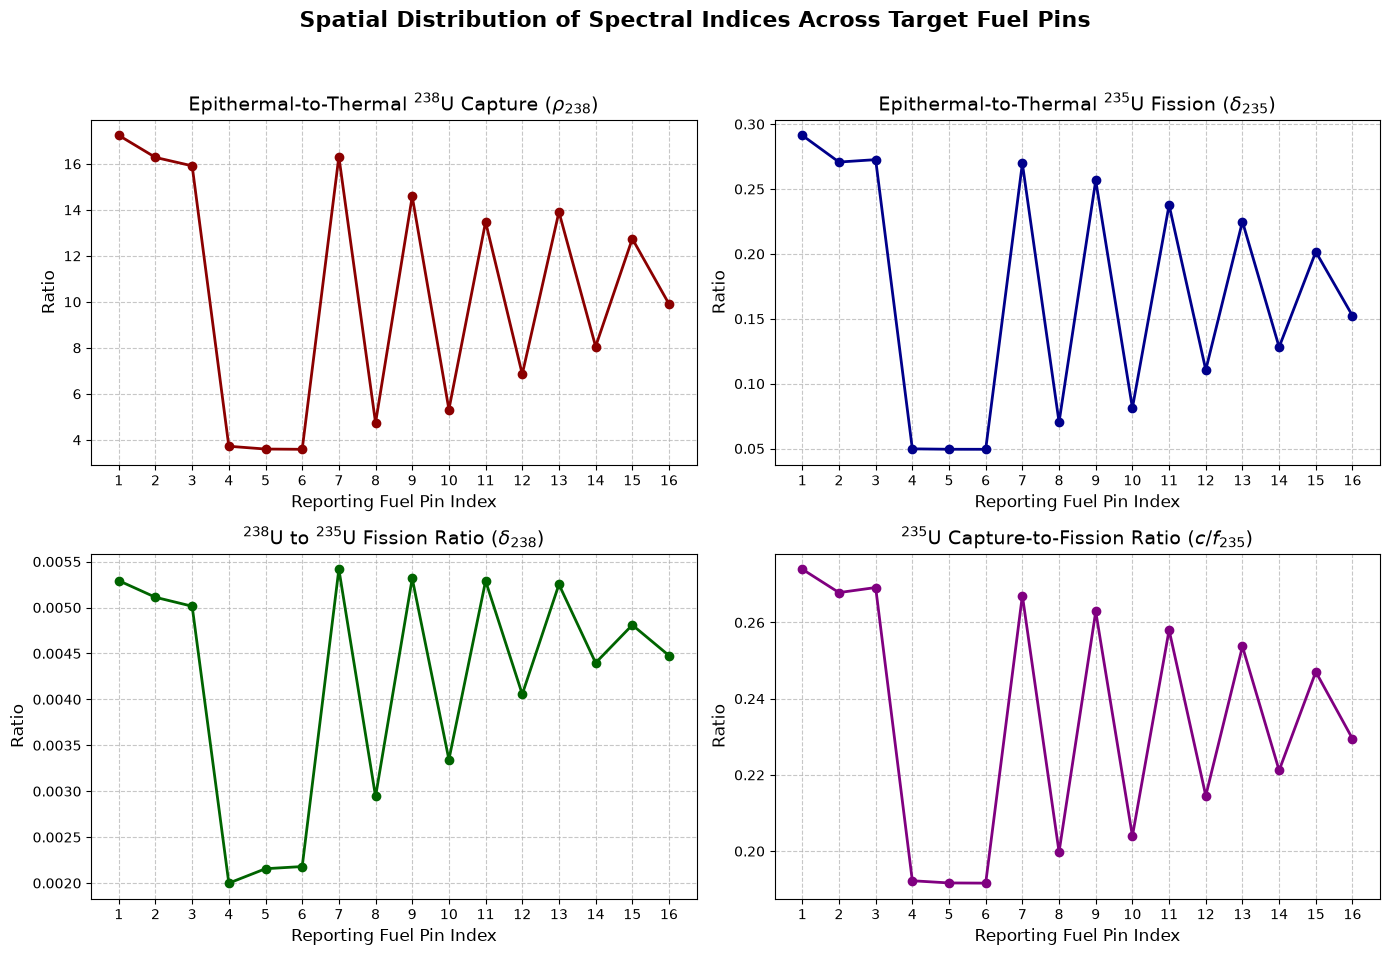

In [20]:
import openmc
import matplotlib.pyplot as plt

# =============================================================================
# DATA EXTRACTION & MATPLOTLIB VISUALIZATION
# =============================================================================

sp = openmc.StatePoint('statepoint.300.h5')
tally_u235 = sp.get_tally(name='U-235 Rates')
tally_u238 = sp.get_tally(name='U-238 Rates')

# Arrays to hold the data for plotting
pins = list(range(1, 17))
rho_238_vals, delta_235_vals, delta_238_vals, c_f_235_vals = [], [], [], []

for i in range(16):
    univ_id = reporting_univs[i].id
    
    # Slice the native arrays
    u235_fiss = tally_u235.get_values(scores=['fission'], filters=[openmc.UniverseFilter], filter_bins=[(univ_id,)])
    u235_cap  = tally_u235.get_values(scores=['(n,gamma)'], filters=[openmc.UniverseFilter], filter_bins=[(univ_id,)])
    u238_fiss = tally_u238.get_values(scores=['fission'], filters=[openmc.UniverseFilter], filter_bins=[(univ_id,)])
    u238_cap  = tally_u238.get_values(scores=['(n,gamma)'], filters=[openmc.UniverseFilter], filter_bins=[(univ_id,)])
    
    # Calculate indices
    u235_fiss_total = u235_fiss[0][0][0] + u235_fiss[1][0][0]
    u238_fiss_total = u238_fiss[0][0][0] + u238_fiss[1][0][0]
    u235_cap_total  = u235_cap[0][0][0] + u235_cap[1][0][0]
    
    rho_238 = u238_cap[1][0][0] / u238_cap[0][0][0]
    delta_235 = u235_fiss[1][0][0] / u235_fiss[0][0][0]
    delta_238 = u238_fiss_total / u235_fiss_total
    c_f_235 = u235_cap_total / u235_fiss_total
    
    # Store data
    rho_238_vals.append(rho_238)
    delta_235_vals.append(delta_235)
    delta_238_vals.append(delta_238)
    c_f_235_vals.append(c_f_235)

# =============================================================================
# GENERATE REPORT-READY PLOTS
# =============================================================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Spatial Distribution of Spectral Indices Across Target Fuel Pins', fontsize=16, fontweight='bold')

# Plot styling function
def format_plot(ax, x, y, title, ylabel, color):
    ax.plot(x, y, marker='o', linestyle='-', color=color, linewidth=2, markersize=6)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Reporting Fuel Pin Index', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xticks(pins)
    ax.grid(True, linestyle='--', alpha=0.7)

# 1. rho_238
format_plot(axs[0, 0], pins, rho_238_vals, r'Epithermal-to-Thermal $^{238}$U Capture ($\rho_{238}$)', 'Ratio', 'darkred')

# 2. delta_235
format_plot(axs[0, 1], pins, delta_235_vals, r'Epithermal-to-Thermal $^{235}$U Fission ($\delta_{235}$)', 'Ratio', 'darkblue')

# 3. delta_238
format_plot(axs[1, 0], pins, delta_238_vals, r'$^{238}$U to $^{235}$U Fission Ratio ($\delta_{238}$)', 'Ratio', 'darkgreen')

# 4. c/f_235
format_plot(axs[1, 1], pins, c_f_235_vals, r'$^{235}$U Capture-to-Fission Ratio ($c/f_{235}$)', 'Ratio', 'purple')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


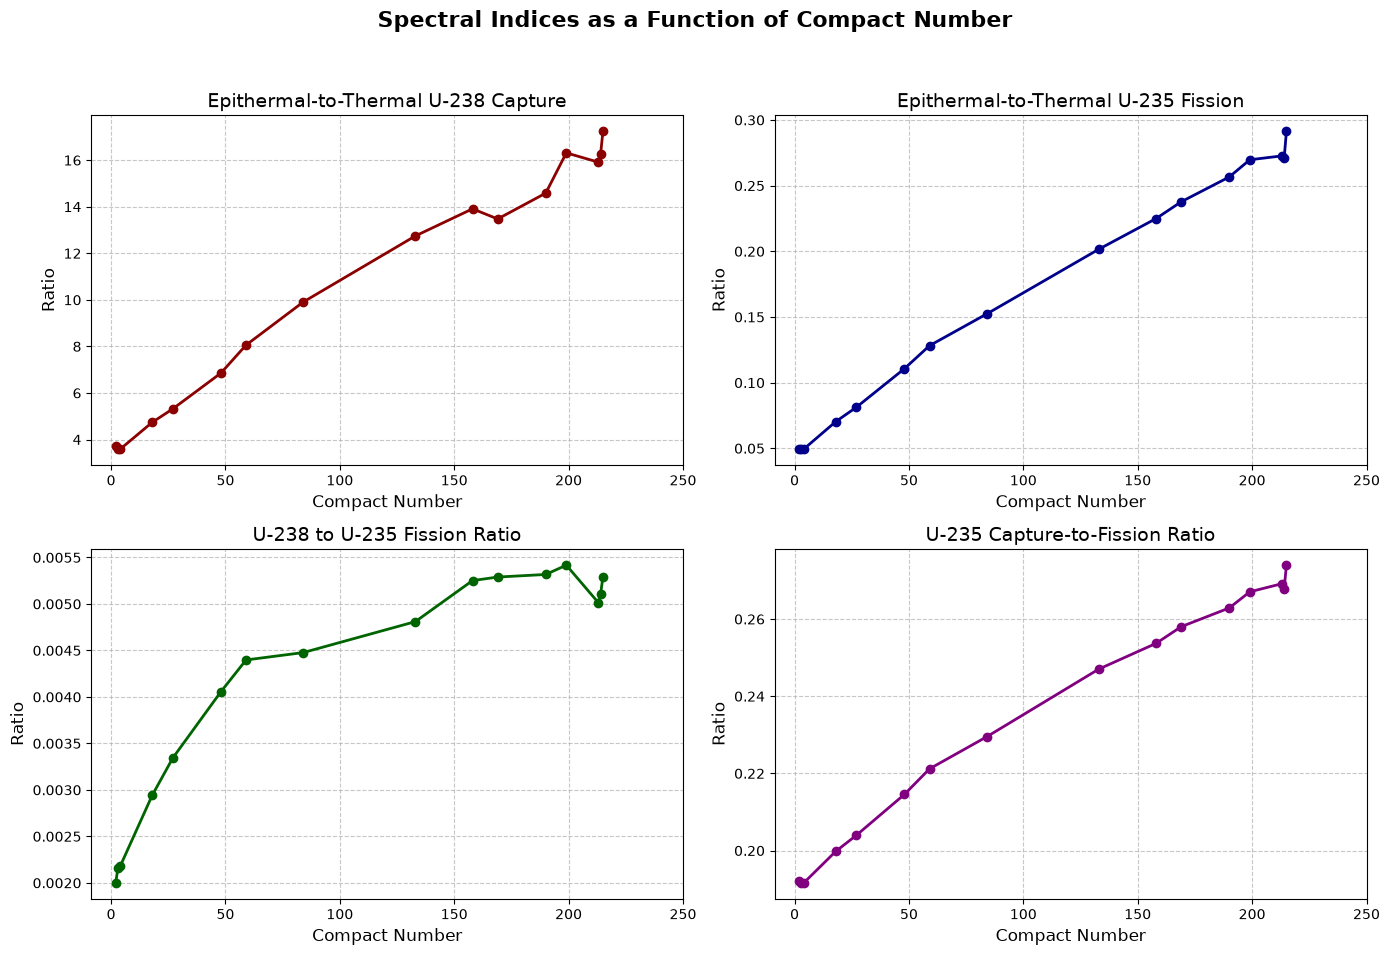

In [27]:
import matplotlib.pyplot as plt

# =============================================================================
# DATA ALIGNMENT & FINAL PLOTTING
# =============================================================================

# The true physical IDs corresponding strictly to Python indices 0 through 15
actual_compacts = [215, 214, 213, 2, 3, 4, 199, 18, 190, 27, 169, 48, 158, 59, 133, 84]

# Zip the physical IDs with your data and force a numerical sort by Compact Number
sorted_data = sorted(zip(actual_compacts, rho_238_vals, delta_235_vals, delta_238_vals, c_f_235_vals))

# Unpack strictly into the sorted arrays
sorted_x, sorted_rho, sorted_d235, sorted_d238, sorted_cf = zip(*sorted_data)

# =============================================================================
# GENERATE AND EXPORT REPORT-READY PLOTS
# =============================================================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Spectral Indices as a Function of Compact Number', fontsize=16, fontweight='bold')

def format_plot(ax, x_data, y_data, title, ylabel, color):
    # Plot strictly using the sorted data
    ax.plot(x_data, y_data, marker='o', linestyle='-', color=color, linewidth=2, markersize=6)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Compact Number', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xticks([0, 50, 100, 150, 200, 250])  
    ax.grid(True, linestyle='--', alpha=0.7)

format_plot(axs[0, 0], sorted_x, sorted_rho, 'Epithermal-to-Thermal U-238 Capture', 'Ratio', 'darkred')
format_plot(axs[0, 1], sorted_x, sorted_d235, 'Epithermal-to-Thermal U-235 Fission', 'Ratio', 'darkblue')
format_plot(axs[1, 0], sorted_x, sorted_d238, 'U-238 to U-235 Fission Ratio', 'Ratio', 'darkgreen')
format_plot(axs[1, 1], sorted_x, sorted_cf, 'U-235 Capture-to-Fission Ratio', 'Ratio', 'purple')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('spectral_indices_final_mapped.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()